# Adaptive Concept Drift-Aware IDS with ADWIN
## 3-Phase Concept Drift Simulation

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import glob
import os
import copy
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score
)
from collections import deque

print('All imports OK')

All imports OK


## 2. ADWIN Implementation

In [2]:
class ADWIN:
    """
    ADaptive WINdowing drift detector.
    Based on: Bifet & Gavalda (2007) 'Learning from Time-Changing Data with Adaptive Windowing'
    """

    def __init__(self, delta=0.002):
        self.delta = delta
        self.window = deque()
        self.total  = 0.0
        self.drift_detected = False
        self.n_detections   = 0

    def add_element(self, value):
        self.drift_detected = False
        self.window.append(value)
        self.total += value
        self._check_drift()

    def _check_drift(self):
        n = len(self.window)
        if n < 5:
            return
        window_list = list(self.window)
        total_sum   = self.total
        running_sum = 0.0
        for i in range(1, n):
            running_sum += window_list[i - 1]
            n0 = i
            n1 = n - i
            mean0 = running_sum / n0
            mean1 = (total_sum - running_sum) / n1
            m = 1.0 / (1.0 / n0 + 1.0 / n1)
            eps_cut = np.sqrt((1.0 / (2.0 * m)) * np.log(4.0 * n / self.delta))
            if abs(mean0 - mean1) >= eps_cut:
                for _ in range(i):
                    removed = self.window.popleft()
                    self.total -= removed
                self.drift_detected = True
                self.n_detections  += 1
                return

    def reset(self):
        self.window.clear()
        self.total = 0.0
        self.drift_detected = False

    @property
    def estimation(self):
        return self.total / len(self.window) if self.window else 0.0

print('ADWIN class defined')

ADWIN class defined


## 3. Build 3-Phase Drift Dataset

The raw dataset has no natural drift (all files look the same).
We simulate concept drift by constructing 3 phases with different attack type distributions:

- **Phase 1 (Train + Stream):** DDoS attacks only — model learns these well
- **Phase 2 (Stream):** DoS + Recon + Mirai attacks — model has not seen these → error spikes → ADWIN fires
- **Phase 3 (Stream):** Web/Application attacks — another distribution shift → ADWIN fires again

This is standard practice in concept drift research when the dataset lacks temporal variation.

In [3]:
DATASET_DIR  = '../datasets/cicids2023/'
SAMPLES_PER_PHASE = 15000  # samples to collect per phase
HOLDOUT_FRAC = 0.15        # fraction of each phase held out from streaming/retraining, for a leak-free final evaluation

# Define which attack types belong to each phase
PHASE1_TYPES = ['DDOS-ICMP_FLOOD', 'DDOS-UDP_FLOOD', 'DDOS-TCP_FLOOD',
                'DDOS-SYN_FLOOD', 'DDOS-PSHACK_FLOOD', 'DDOS-RSTFINFLOOD',
                'DDOS-SYNONYMOUSIP_FLOOD', 'DDOS-ACK_FRAGMENTATION',
                'DDOS-ICMP_FRAGMENTATION', 'DDOS-UDP_FRAGMENTATION',
                'DDOS-HTTP_FLOOD', 'DDOS-SLOWLORIS', 'BENIGN']

PHASE2_TYPES = ['DOS-UDP_FLOOD', 'DOS-TCP_FLOOD', 'DOS-SYN_FLOOD', 'DOS-HTTP_FLOOD',
                'RECON-HOSTDISCOVERY', 'RECON-PORTSCAN', 'RECON-OSSCAN', 'RECON-PINGSWEEP',
                'MIRAI-GREIP_FLOOD', 'MIRAI-GREETH_FLOOD', 'MIRAI-UDPPLAIN',
                'VULNERABILITYSCAN', 'BENIGN']

PHASE3_TYPES = ['XSS', 'SQLINJECTION', 'COMMANDINJECTION', 'BROWSERHIJACKING',
                'DNS_SPOOFING', 'MITM-ARPSPOOFING', 'BACKDOOR_MALWARE',
                'DICTIONARYBRUTEFORCE', 'BENIGN']

def collect_phase_data(label_set, n_samples):
    """Read CSVs until we have enough rows matching the given label set."""
    csv_files = sorted(glob.glob(os.path.join(DATASET_DIR, 'Merged*.csv')))
    chunks = []
    collected = 0
    for f in csv_files:
        df = pd.read_csv(f).dropna()
        df = df[df['Label'].isin(label_set)]
        if len(df) == 0:
            continue
        need = n_samples - collected
        chunks.append(df.iloc[:need])
        collected += len(chunks[-1])
        if collected >= n_samples:
            break
    return pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()

def split_stream_holdout(df, frac=HOLDOUT_FRAC, seed=42, min_class_size=5):
    """
    Split a phase's data into a 'stream' portion (the only data ever fed through
    initial training / ADWIN / retraining) and a 'holdout' portion that is NEVER
    seen by any model. The holdout is what the final classification report should
    be evaluated on, so results reflect generalisation rather than memorisation of
    samples that were also used to retrain the adaptive model mid-stream.

    Classes with too few rows to safely carve out a holdout slice are kept
    entirely in the stream, so rare attack types are not starved of training data.
    """
    holdout_idx = []
    for _, group in df.groupby('Label'):
        n = len(group)
        n_hold = int(round(n * frac))
        if n < min_class_size or n_hold < 1:
            continue
        holdout_idx.extend(group.sample(n=n_hold, random_state=seed).index)
    holdout_df = df.loc[holdout_idx].reset_index(drop=True)
    stream_df  = df.drop(index=holdout_idx).reset_index(drop=True)
    return stream_df, holdout_df

print('Collecting Phase 1 (DDoS)...')
df_phase1_full = collect_phase_data(PHASE1_TYPES, SAMPLES_PER_PHASE)
df_phase1, df_phase1_holdout = split_stream_holdout(df_phase1_full)
print(f'  Phase 1: {len(df_phase1_full)} samples ({len(df_phase1)} stream / {len(df_phase1_holdout)} holdout), classes: {df_phase1_full["Label"].nunique()}')

print('Collecting Phase 2 (DoS + Recon + Mirai)...')
df_phase2_full = collect_phase_data(PHASE2_TYPES, SAMPLES_PER_PHASE)
df_phase2, df_phase2_holdout = split_stream_holdout(df_phase2_full)
print(f'  Phase 2: {len(df_phase2_full)} samples ({len(df_phase2)} stream / {len(df_phase2_holdout)} holdout), classes: {df_phase2_full["Label"].nunique()}')

print('Collecting Phase 3 (Web/Application Attacks)...')
df_phase3_full = collect_phase_data(PHASE3_TYPES, SAMPLES_PER_PHASE)
df_phase3, df_phase3_holdout = split_stream_holdout(df_phase3_full)
print(f'  Phase 3: {len(df_phase3_full)} samples ({len(df_phase3)} stream / {len(df_phase3_holdout)} holdout), classes: {df_phase3_full["Label"].nunique()}')

# Fit encoder on all labels across all phases (stream + holdout, so holdout labels are always known)
all_labels = pd.concat([df_phase1_full['Label'], df_phase2_full['Label'], df_phase3_full['Label']])
encoder = LabelEncoder()
encoder.fit(all_labels)
print(f'\nTotal classes across all phases: {len(encoder.classes_)}')
print('Classes:', list(encoder.classes_))

  Phase 1: 15000 samples (12751 stream / 2249 holdout), classes: 13
  Phase 2: 15000 samples (12750 stream / 2250 holdout), classes: 13
  Phase 3: 15000 samples (12749 stream / 2251 holdout), classes: 9

Total classes across all phases: 33
Classes: ['BACKDOOR_MALWARE', 'BENIGN', 'BROWSERHIJACKING', 'COMMANDINJECTION', 'DDOS-ACK_FRAGMENTATION', 'DDOS-HTTP_FLOOD', 'DDOS-ICMP_FLOOD', 'DDOS-ICMP_FRAGMENTATION', 'DDOS-PSHACK_FLOOD', 'DDOS-RSTFINFLOOD', 'DDOS-SLOWLORIS', 'DDOS-SYNONYMOUSIP_FLOOD', 'DDOS-SYN_FLOOD', 'DDOS-TCP_FLOOD', 'DDOS-UDP_FLOOD', 'DDOS-UDP_FRAGMENTATION', 'DICTIONARYBRUTEFORCE', 'DNS_SPOOFING', 'DOS-HTTP_FLOOD', 'DOS-SYN_FLOOD', 'DOS-TCP_FLOOD', 'DOS-UDP_FLOOD', 'MIRAI-GREETH_FLOOD', 'MIRAI-GREIP_FLOOD', 'MIRAI-UDPPLAIN', 'MITM-ARPSPOOFING', 'RECON-HOSTDISCOVERY', 'RECON-OSSCAN', 'RECON-PINGSWEEP', 'RECON-PORTSCAN', 'SQLINJECTION', 'VULNERABILITYSCAN', 'XSS']


## 4. Train Initial Static Model on Phase 1

In [4]:
feature_cols = [c for c in df_phase1.columns if c != 'Label']

X1 = df_phase1[feature_cols].values
y1 = encoder.transform(df_phase1['Label'])

# Use 70% of Phase 1 for initial training
INIT_SPLIT = int(len(X1) * 0.7)
X_train_init = X1[:INIT_SPLIT]
y_train_init = y1[:INIT_SPLIT]

static_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
static_model.fit(X_train_init, y_train_init)
print(f'Static model trained on {len(X_train_init)} Phase 1 samples (DDoS only)')
print('This model has never seen DoS, Recon, Mirai, or Web attack types.')

Static model trained on 8925 Phase 1 samples (DDoS only)
This model has never seen DoS, Recon, Mirai, or Web attack types.


## 5. Stream All 3 Phases Through ADWIN

In [5]:
CHUNK_SIZE      = 500    # samples per chunk
RETRAIN_WINDOW  = 5000   # max buffer size (short-term, new-phase buffer)
ADWIN_DELTA     = 0.002  # ADWIN sensitivity
WARMUP_SAMPLES  = 1500   # new-phase samples to collect before retraining

LONG_TERM_MEMORY_SIZE = 6000  # capacity of the rehearsal reservoir (spans ALL phases seen so far)
REHEARSAL_SAMPLES     = 1000  # samples drawn from long-term memory and mixed into each retrain

rng = np.random.RandomState(42)

adaptive_model   = copy.deepcopy(static_model)
detector         = ADWIN(delta=ADWIN_DELTA)

recent_X = deque(maxlen=RETRAIN_WINDOW)
recent_y = deque(maxlen=RETRAIN_WINDOW)

# Seed buffer with initial training data
for xi, yi in zip(X_train_init, y_train_init):
    recent_X.append(xi)
    recent_y.append(yi)

# ---- Long-term rehearsal memory ----
# Reservoir sample (Algorithm R) over the ENTIRE stream, never cleared on drift.
# This is what prevents catastrophic forgetting: when we retrain on new-phase data,
# we mix in a representative sample of everything seen so far, not just the newest phase.
long_term_X = []
long_term_y = []
total_seen  = 0

def reservoir_add(xi, yi):
    global total_seen
    if len(long_term_X) < LONG_TERM_MEMORY_SIZE:
        long_term_X.append(xi)
        long_term_y.append(yi)
    else:
        j = rng.randint(0, total_seen + 1)
        if j < LONG_TERM_MEMORY_SIZE:
            long_term_X[j] = xi
            long_term_y[j] = yi
    total_seen += 1

# Seed the reservoir with the same initial training data too
for xi, yi in zip(X_train_init, y_train_init):
    reservoir_add(xi, yi)

pending_retrain  = False  # True after drift, waiting for warmup
post_drift_count = 0      # new-phase samples collected since drift

chunk_ids, static_accs, adaptive_accs, error_rates = [], [], [], []
# Multi-class macro F1 per chunk, computed only over the classes present in that
# chunk (a 500-sample chunk rarely contains all 33 classes, so scoring against the
# full label set would mostly measure which classes didn't show up, not model quality).
static_f1s, adaptive_f1s = [], []
drift_events, retrain_events = [], []
phase_boundaries = []

chunk_id = 0

stream_parts = [
    ("Phase 1 (DDoS)",            df_phase1.iloc[INIT_SPLIT:]),
    ("Phase 2 (DoS+Recon+Mirai)", df_phase2),
    ("Phase 3 (Web Attacks)",     df_phase3),
]

for phase_name, df_part in stream_parts:
    X_part = df_part[feature_cols].values
    y_part = encoder.transform(df_part["Label"])
    phase_boundaries.append(chunk_id)
    print("\nStreaming " + phase_name + " (" + str(len(X_part)) + " samples)...")

    for i in range(0, len(X_part), CHUNK_SIZE):
        X_chunk = X_part[i : i + CHUNK_SIZE]
        y_chunk = y_part[i : i + CHUNK_SIZE]
        if len(X_chunk) == 0:
            continue

        static_preds   = static_model.predict(X_chunk)
        adaptive_preds = adaptive_model.predict(X_chunk)

        static_acc   = accuracy_score(y_chunk, static_preds)
        adaptive_acc = accuracy_score(y_chunk, adaptive_preds)

        chunk_labels = np.unique(y_chunk)
        static_f1   = f1_score(y_chunk, static_preds,   labels=chunk_labels, average='macro', zero_division=0)
        adaptive_f1 = f1_score(y_chunk, adaptive_preds, labels=chunk_labels, average='macro', zero_division=0)

        for xi, yi, yp in zip(X_chunk, y_chunk, adaptive_preds):
            error = 1.0 if yi != yp else 0.0
            detector.add_element(error)
            recent_X.append(xi)
            recent_y.append(yi)
            reservoir_add(xi, yi)  # long-term memory sees every sample, regardless of drift state

            # DRIFT DETECTED: clear short-term buffer, begin warmup (long-term memory is untouched)
            if detector.drift_detected and not pending_retrain:
                recent_X.clear()
                recent_y.clear()
                recent_X.append(xi)
                recent_y.append(yi)
                post_drift_count = 1
                pending_retrain  = True
                detector.reset()
                drift_events.append(chunk_id)
                print("  [Chunk " + str(chunk_id) + "] DRIFT DETECTED -> clearing short-term buffer, collecting new-phase data...")

            elif pending_retrain:
                post_drift_count += 1
                if post_drift_count >= WARMUP_SAMPLES and len(recent_X) >= 100:
                    Xr_new = np.array(recent_X)
                    yr_new = np.array(recent_y)

                    # Rehearsal: mix in a sample from long-term memory so the retrained
                    # model doesn't fully forget earlier phases.
                    n_rehearsal = min(REHEARSAL_SAMPLES, len(long_term_X))
                    if n_rehearsal > 0:
                        idx = rng.choice(len(long_term_X), size=n_rehearsal, replace=False)
                        Xr_rehearsal = np.array(long_term_X)[idx]
                        yr_rehearsal = np.array(long_term_y)[idx]
                        Xr = np.vstack([Xr_new, Xr_rehearsal])
                        yr = np.concatenate([yr_new, yr_rehearsal])
                    else:
                        Xr, yr = Xr_new, yr_new

                    adaptive_model = RandomForestClassifier(
                        n_estimators=50, class_weight="balanced", random_state=42, n_jobs=-1)
                    adaptive_model.fit(Xr, yr)
                    pending_retrain  = False
                    post_drift_count = 0
                    retrain_events.append(chunk_id)
                    print("  [Chunk " + str(chunk_id) + "] RETRAINED on " + str(len(Xr_new)) + " new-phase + " + str(n_rehearsal) + " rehearsal samples (" + str(len(Xr)) + " total)")

        chunk_ids.append(chunk_id)
        static_accs.append(static_acc)
        adaptive_accs.append(adaptive_acc)
        static_f1s.append(static_f1)
        adaptive_f1s.append(adaptive_f1)
        error_rates.append(detector.estimation)
        chunk_id += 1

print("\nDone! " + str(chunk_id) + " chunks | " + str(len(drift_events)) + " drifts | " + str(len(retrain_events)) + " retrains")



Streaming Phase 1 (DDoS) (3826 samples)...

Streaming Phase 2 (DoS+Recon+Mirai) (12750 samples)...
  [Chunk 8] DRIFT DETECTED -> clearing short-term buffer, collecting new-phase data...
  [Chunk 11] RETRAINED on 1500 new-phase + 1000 rehearsal samples (2500 total)
  [Chunk 12] DRIFT DETECTED -> clearing short-term buffer, collecting new-phase data...
  [Chunk 15] RETRAINED on 1500 new-phase + 1000 rehearsal samples (2500 total)

Streaming Phase 3 (Web Attacks) (12749 samples)...
  [Chunk 34] DRIFT DETECTED -> clearing short-term buffer, collecting new-phase data...
  [Chunk 37] RETRAINED on 1500 new-phase + 1000 rehearsal samples (2500 total)
  [Chunk 38] DRIFT DETECTED -> clearing short-term buffer, collecting new-phase data...
  [Chunk 41] RETRAINED on 1500 new-phase + 1000 rehearsal samples (2500 total)

Done! 60 chunks | 4 drifts | 4 retrains


## 6. Results: Accuracy Over Time

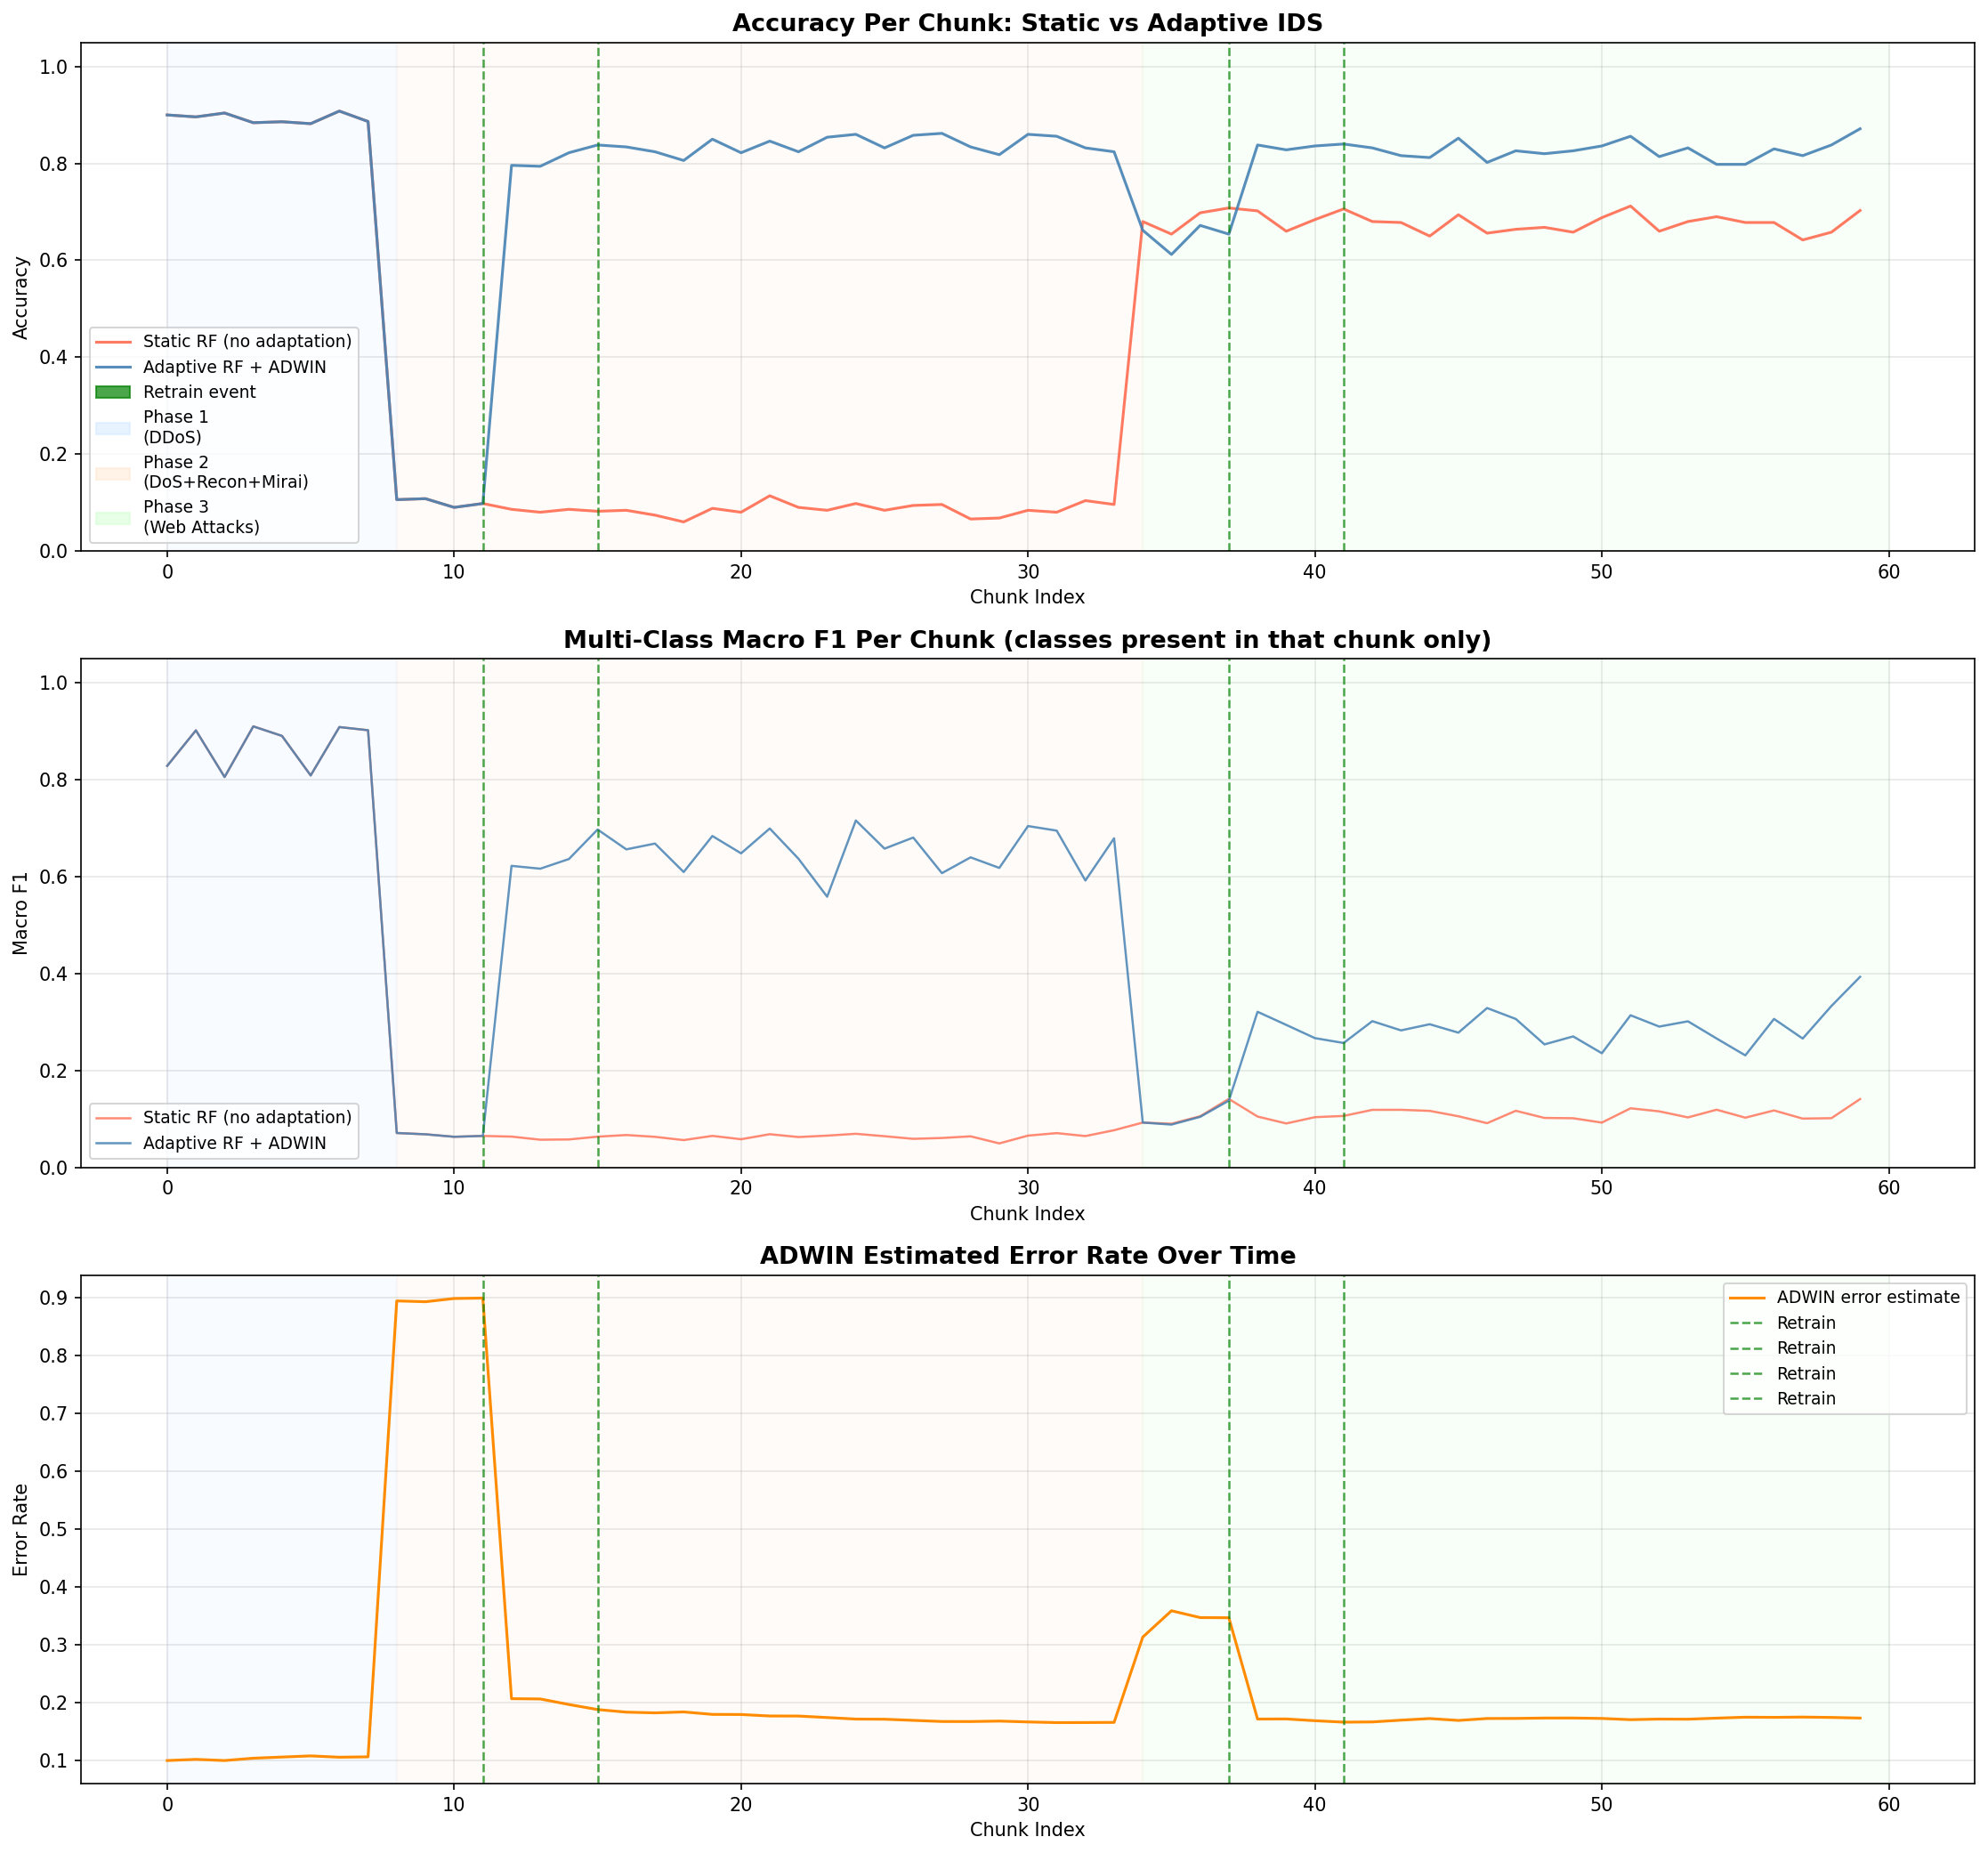

Plot saved.


In [6]:
phase_labels = ['Phase 1\n(DDoS)', 'Phase 2\n(DoS+Recon+Mirai)', 'Phase 3\n(Web Attacks)']
phase_colors = ['#d1e8ff', '#ffe8d1', '#d1ffd1']

fig, axes = plt.subplots(3, 1, figsize=(15, 14))

# -- Panel 1: Accuracy --
ax = axes[0]

# Shade phases
boundaries = phase_boundaries + [chunk_id]
for idx in range(len(phase_boundaries)):
    ax.axvspan(boundaries[idx], boundaries[idx+1], alpha=0.15,
               color=phase_colors[idx], label=phase_labels[idx])

ax.plot(chunk_ids, static_accs,   color='tomato',    linewidth=1.5, label='Static RF (no adaptation)', alpha=0.85)
ax.plot(chunk_ids, adaptive_accs, color='steelblue', linewidth=1.5, label='Adaptive RF + ADWIN',       alpha=0.9)

for r in retrain_events:
    ax.axvline(x=r, color='green', linewidth=1.2, alpha=0.7, linestyle='--')

retrain_line = mpatches.Patch(color='green', alpha=0.7, label='Retrain event')
handles = ax.lines[:2] + [retrain_line]
for idx in range(len(phase_labels)):
    handles.append(mpatches.Patch(color=phase_colors[idx], alpha=0.5, label=phase_labels[idx]))
ax.legend(handles=handles, loc='lower left', fontsize=9)
ax.set_title('Accuracy Per Chunk: Static vs Adaptive IDS', fontsize=13, fontweight='bold')
ax.set_xlabel('Chunk Index')
ax.set_ylabel('Accuracy')
ax.set_ylim([0.0, 1.05])
ax.grid(True, alpha=0.3)

# -- Panel 2: Multi-class Macro F1 --
ax3 = axes[1]
for idx in range(len(phase_boundaries)):
    ax3.axvspan(boundaries[idx], boundaries[idx+1], alpha=0.15, color=phase_colors[idx])
ax3.plot(chunk_ids, static_f1s,   color='tomato',    linewidth=1.2, label='Static RF (no adaptation)', alpha=0.75)
ax3.plot(chunk_ids, adaptive_f1s, color='steelblue', linewidth=1.2, label='Adaptive RF + ADWIN',       alpha=0.85)
for r in retrain_events:
    ax3.axvline(x=r, color='green', linewidth=1.2, alpha=0.7, linestyle='--')
ax3.set_title('Multi-Class Macro F1 Per Chunk (classes present in that chunk only)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Chunk Index')
ax3.set_ylabel('Macro F1')
ax3.set_ylim([0.0, 1.05])
ax3.legend(loc='lower left', fontsize=9)
ax3.grid(True, alpha=0.3)

# -- Panel 3: ADWIN Error Rate --
ax2 = axes[2]
for idx in range(len(phase_boundaries)):
    ax2.axvspan(boundaries[idx], boundaries[idx+1], alpha=0.15, color=phase_colors[idx])
ax2.plot(chunk_ids, error_rates, color='darkorange', linewidth=1.5, label='ADWIN error estimate')
for r in retrain_events:
    ax2.axvline(x=r, color='green', linewidth=1.2, alpha=0.7, linestyle='--', label='Retrain')
ax2.set_title('ADWIN Estimated Error Rate Over Time', fontsize=13, fontweight='bold')
ax2.set_xlabel('Chunk Index')
ax2.set_ylabel('Error Rate')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')


## 7. Summary Metrics

In [7]:
static_mean   = np.mean(static_accs)
adaptive_mean = np.mean(adaptive_accs)
static_f1_mean   = np.mean(static_f1s)
adaptive_f1_mean = np.mean(adaptive_f1s)

print('=' * 50)
print('      SUMMARY METRICS')
print('=' * 50)
print(f'Static  RF  -- mean accuracy  : {static_mean:.4f}')
print(f'Adaptive RF -- mean accuracy  : {adaptive_mean:.4f}')
print(f'Improvement (accuracy)        : {adaptive_mean - static_mean:+.4f}')
print(f'Static  RF  -- mean macro F1  : {static_f1_mean:.4f}')
print(f'Adaptive RF -- mean macro F1  : {adaptive_f1_mean:.4f}')
print(f'Improvement (macro F1)        : {adaptive_f1_mean - static_f1_mean:+.4f}')
print(f'Total drift events detected   : {len(drift_events)}')
print(f'Total retraining events       : {len(retrain_events)}')
print(f'Total chunks streamed         : {len(chunk_ids)}')
print('=' * 50)

# Per-phase breakdown
boundaries_full = phase_boundaries + [chunk_id]
phase_names = ['Phase 1 (DDoS)', 'Phase 2 (DoS+Recon+Mirai)', 'Phase 3 (Web Attacks)']
print('\nPer-Phase Accuracy:')
for idx, name in enumerate(phase_names):
    start = boundaries_full[idx]
    end   = boundaries_full[idx + 1]
    s_acc = np.mean(static_accs[start:end])
    a_acc = np.mean(adaptive_accs[start:end])
    print(f'  {name}: Static={s_acc:.3f}  Adaptive={a_acc:.3f}  D={a_acc-s_acc:+.3f}')

print('\nPer-Phase Macro F1 (per-chunk, streamed data):')
for idx, name in enumerate(phase_names):
    start = boundaries_full[idx]
    end   = boundaries_full[idx + 1]
    s_f1 = np.mean(static_f1s[start:end])
    a_f1 = np.mean(adaptive_f1s[start:end])
    print(f'  {name}: Static={s_f1:.3f}  Adaptive={a_f1:.3f}  D={a_f1-s_f1:+.3f}')


      SUMMARY METRICS
Static  RF  -- mean accuracy  : 0.4509
Adaptive RF -- mean accuracy  : 0.7785
Improvement (accuracy)        : +0.3276
Static  RF  -- mean macro F1  : 0.1905
Adaptive RF -- mean macro F1  : 0.4727
Improvement (macro F1)        : +0.2821
Total drift events detected   : 4
Total retraining events       : 4
Total chunks streamed         : 60

Per-Phase Accuracy:
  Phase 1 (DDoS): Static=0.893  Adaptive=0.893  D=+0.000
  Phase 2 (DoS+Recon+Mirai): Static=0.088  Adaptive=0.721  D=+0.633
  Phase 3 (Web Attacks): Static=0.678  Adaptive=0.801  D=+0.123

Per-Phase Macro F1 (per-chunk, streamed data):
  Phase 1 (DDoS): Static=0.870  Adaptive=0.870  D=+0.000
  Phase 2 (DoS+Recon+Mirai): Static=0.064  Adaptive=0.561  D=+0.497
  Phase 3 (Web Attacks): Static=0.108  Adaptive=0.262  D=+0.154


## 8. Final Classification Report

In [8]:
# Evaluate on held-out data that was NEVER streamed or used for retraining,
# so these numbers reflect true generalisation rather than memorisation of the
# same samples the adaptive model was just retrained on mid-stream.
print(f'Holdout sizes -> Phase 1: {len(df_phase1_holdout)}, Phase 2: {len(df_phase2_holdout)}, Phase 3: {len(df_phase3_holdout)}')

def evaluate_holdout(name, df_holdout):
    X_h = df_holdout[feature_cols].values
    y_h = encoder.transform(df_holdout['Label'])
    present_labels = sorted(set(y_h))
    present_names  = encoder.classes_[present_labels]

    y_pred_adaptive = adaptive_model.predict(X_h)
    y_pred_static   = static_model.predict(X_h)

    print(f'\n── {name} — Adaptive Model ──')
    print(classification_report(y_h, y_pred_adaptive,
                                labels=present_labels, target_names=present_names, zero_division=0))
    print(f'── {name} — Static Model ──')
    print(classification_report(y_h, y_pred_static,
                                labels=present_labels, target_names=present_names, zero_division=0))

evaluate_holdout('Phase 1 (DDoS)', df_phase1_holdout)
evaluate_holdout('Phase 2 (DoS+Recon+Mirai)', df_phase2_holdout)
evaluate_holdout('Phase 3 (Web Attacks) — hardest', df_phase3_holdout)

Holdout sizes -> Phase 1: 2249, Phase 2: 2250, Phase 3: 2251

-- Phase 1 (DDoS) -- Adaptive Model --
                         precision    recall  f1-score   support

                 BENIGN       0.96      0.96      0.96        73
 DDOS-ACK_FRAGMENTATION       1.00      1.00      1.00        17
        DDOS-HTTP_FLOOD       0.00      0.00      0.00         2
        DDOS-ICMP_FLOOD       1.00      1.00      1.00       475
DDOS-ICMP_FRAGMENTATION       1.00      0.97      0.98        30
      DDOS-PSHACK_FLOOD       1.00      0.99      0.99       257
       DDOS-RSTFINFLOOD       1.00      1.00      1.00       260
         DDOS-SLOWLORIS       0.00      0.00      0.00         2
DDOS-SYNONYMOUSIP_FLOOD       0.51      0.34      0.41       222
         DDOS-SYN_FLOOD       0.54      0.34      0.42       256
         DDOS-TCP_FLOOD       0.99      0.39      0.56       304
         DDOS-UDP_FLOOD       1.00      0.54      0.70       335
 DDOS-UDP_FRAGMENTATION       1.00      0.94      0.9

## 9. Save Results

In [9]:
results_df = pd.DataFrame({
    'chunk_id':         chunk_ids,
    'static_acc':       static_accs,
    'adaptive_acc':     adaptive_accs,
    'static_macro_f1':  static_f1s,
    'adaptive_macro_f1':adaptive_f1s,
    'adwin_error_rate': error_rates,
    'retrain':          [1 if c in retrain_events else 0 for c in chunk_ids]
})

results_df.to_csv('../results/adaptive_ids_results.csv', index=False)
print('Results saved to ../results/adaptive_ids_results.csv')
results_df.tail(10)


Results saved to ../results/adaptive_ids_results.csv


    chunk_id  static_acc  adaptive_acc  static_macro_f1  adaptive_macro_f1  adwin_error_rate  retrain
50        50    0.688000      0.836000         0.092324           0.235460          0.172781        0
51        51    0.712000      0.856000         0.121814           0.313819          0.170664        0
52        52    0.660000      0.814000         0.115546           0.290477          0.171714        0
53        53    0.680000      0.832000         0.103030           0.301393          0.171476        0
54        54    0.690000      0.798000         0.118904           0.265869          0.173316        0
55        55    0.678000      0.798000         0.102479           0.231053          0.174946        0
56        56    0.678000      0.830000         0.117403           0.306318          0.174680        0
57        57    0.642000      0.816000         0.100564           0.265741          0.175156        0
58        58    0.658000      0.838000         0.101418           0.332948        